<a href="https://colab.research.google.com/github/Leo5436/dataco-supply-chain-prediction/blob/main/Supply_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. 資料檢視


In [ ]:
!pip install shap scipy joblib -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


#檢視在什麼環境
try:
  from google.colab import drive
  drive.mount('/content/drive')
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

DEFAULT_DATA_PATH = (
    '/content/drive/MyDrive/Data science/DataCoSupplyChainDataset.csv'
    if IN_COLAB
    else 'data/sample_orders.csv'
)


DATA_PATH     = os.getenv('DATA_PATH', DEFAULT_DATA_PATH)
SEARCH_N_ITER = int(os.getenv('SEARCH_N_ITER', '25'))
CV_FOLDS      = int(os.getenv('CV_FOLDS', '5'))

print(f"執行環境: {'Colab' if IN_COLAB else 'CI / 本機'}")
print(f"資料來源: {DATA_PATH}")
print(f"調參次數: {SEARCH_N_ITER} | CV 折數: {CV_FOLDS}")

# ---------- 提早失敗：給出看得懂的錯誤訊息 ----------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"找不到資料檔：{DATA_PATH}\n"
        "若在 Colab：請確認 Drive 已掛載，且路徑的大小寫、空格完全正確。\n"
        "若在 CI：請確認 data/sample_orders.csv 已 commit 到 repo。"
    )

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

df = pd.read_csv(DATA_PATH, encoding='latin-1')

print("資料維度：", df.shape)   # 約 (180519, 53)
print("\n欄位清單：")
print(df.columns.tolist())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
執行環境: Colab
資料來源: /content/drive/MyDrive/Data science/DataCoSupplyChainDataset.csv
調參次數: 25 | CV 折數: 5
資料維度： (180519, 53)

欄位清單：
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order It

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
key_cols = [
    'Days for shipping (real)',        # 迴歸目標：實際運送天數
    'Days for shipment (scheduled)',   # 排定運送天數
    'Late_delivery_risk',              # 分類目標：是否遲交 (0/1)
    'Delivery Status',                 # 交付狀態
    'Shipping Mode',                   # 運送方式 (Standard/First/Second/Same Day)
    'Type',                            # 付款方式
    'Category Name',                   # 商品類別
    'Customer Segment',                # 客戶區隔
    'Order Region',                    # 訂單地區
    'Market',                          # 市場
    'Order Item Quantity',             # 訂購數量
    'Sales',                           # 銷售額
    'Order Item Discount Rate']        # 折扣率]

df[key_cols].head(10)


,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Delivery Status,Shipping Mode,Type,Category Name,Customer Segment,Order Region,Market,Order Item Quantity,Sales,Order Item Discount Rate
0,3,4,0,Advance shipping,Standard Class,DEBIT,Sporting Goods,Consumer,Southeast Asia,Pacific Asia,1,327.75,0.04
1,5,4,1,Late delivery,Standard Class,TRANSFER,Sporting Goods,Consumer,South Asia,Pacific Asia,1,327.75,0.05
2,4,4,0,Shipping on time,Standard Class,CASH,Sporting Goods,Consumer,South Asia,Pacific Asia,1,327.75,0.06
3,3,4,0,Advance shipping,Standard Class,DEBIT,Sporting Goods,Home Office,Oceania,Pacific Asia,1,327.75,0.07
4,2,4,0,Advance shipping,Standard Class,PAYMENT,Sporting Goods,Corporate,Oceania,Pacific Asia,1,327.75,0.09
5,6,4,0,Shipping canceled,Standard Class,TRANSFER,Sporting Goods,Consumer,Oceania,Pacific Asia,1,327.75,0.10
6,2,1,1,Late delivery,First Class,DEBIT,Sporting Goods,Home Office,Eastern Asia,Pacific Asia,1,327.75,0.12
7,2,1,1,Late delivery,First Class,TRANSFER,Sporting Goods,Corporate,Eastern Asia,Pacific Asia,1,327.75,0.13
8,3,2,1,Late delivery,Second Class,CASH,Sporting Goods,Corporate,Eastern Asia,Pacific Asia,1,327.75,0.15
9,2,1,1,Late delivery,First Class,CASH,Sporting Goods,Corporate,Eastern Asia,Pacific Asia,1,327.75,0.16


In [ ]:
missing = df.isnull().sum()
missing = missing[missing >0].sort_values(ascending=False)
print("有缺失的欄位：")
print(missing)

print("\n遲交風險分佈：")
print(df['Late_delivery_risk'].value_counts(normalize=True).round(3))

有缺失的欄位：
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

遲交風險分佈：
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


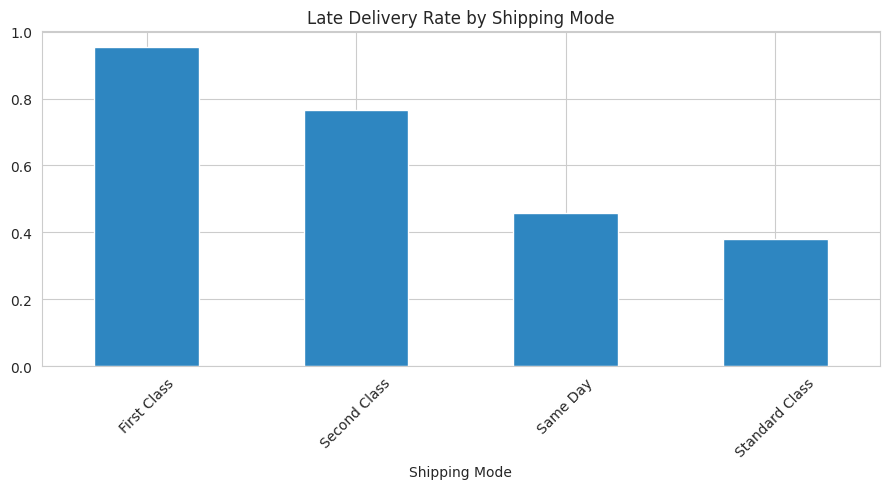

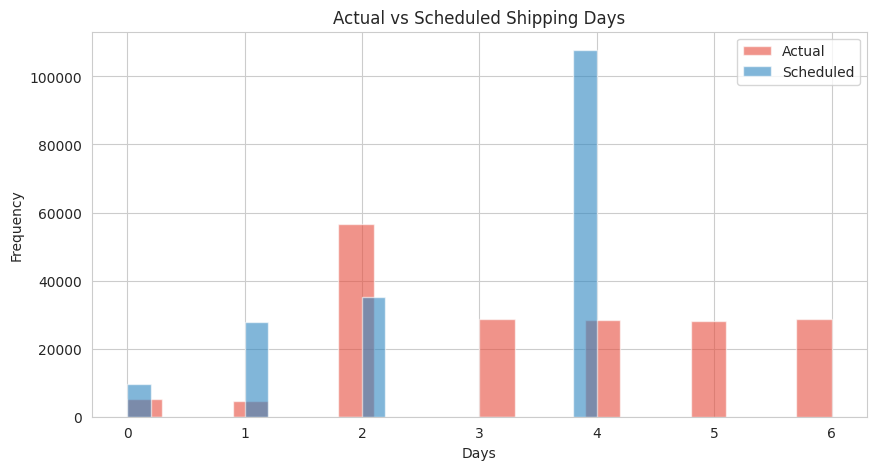

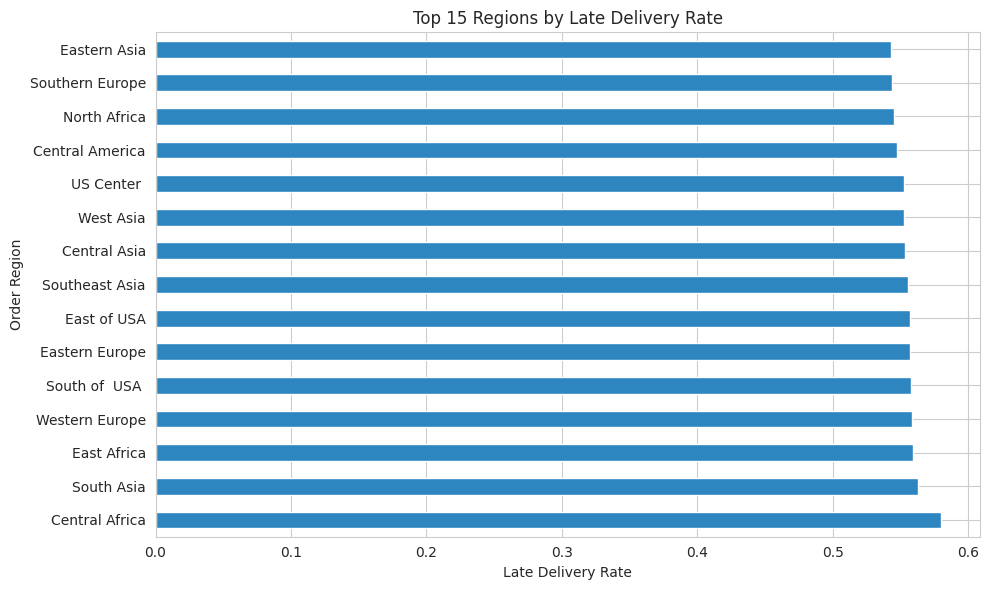

In [ ]:
# 遲交率 by 運送方式
plt.figure(figsize=(9,5))
late_by_mode = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending = False)
late_by_mode.plot(kind = 'bar',color='#2E86C1')
plt.title('Late Delivery Rate by Shipping Mode')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# 實際 vs 排定運送天數
plt.figure(figsize=(10,5))
plt.hist(df['Days for shipping (real)'], bins = 20 , alpha = 0.6, label= 'Actual', color = '#E74C3C')
plt.hist(df['Days for shipment (scheduled)'], bins = 20 , alpha = 0.6, label= 'Scheduled', color = '#2E86C1')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.title('Actual vs Scheduled Shipping Days')
plt.legend()
plt.show()

# 遲交率 by 地區（前 15 名）
plt.figure(figsize=(10, 6))
late_by_region = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False).head(15)
late_by_region.plot(kind='barh', color='#2E86C1')
plt.title('Top 15 Regions by Late Delivery Rate')
plt.xlabel('Late Delivery Rate')
plt.tight_layout()
plt.show()

# 2. 資料清洗


In [ ]:
# 排除要預測的結果變數
leakage_cols = [
    'Delivery Status',
    'Days for shipping (real)',  # 迴歸目標
]

# 個資與識別碼欄位（對預測無用，且含隱私）
id_pii_cols = [
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
    'Customer Street', 'Product Image', 'Order Zipcode', 'Customer Zipcode',
    'Order Id', 'Order Item Id', 'Product Description',
]


# 處理缺失值
cols_to_drop = [ c for c in (leakage_cols + id_pii_cols) if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

# 處理缺失過多的欄位
missing_pct = df_clean.isnull().sum() / len(df_clean)
high_missing  = missing_pct[missing_pct > 0.3].index.tolist()
print("缺失超過30%的欄位將被移除：", high_missing)
df_clean = df_clean.drop(columns= high_missing)

# 缺失值填補
for col in df_clean.select_dtypes(include=[np.number]).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print('清洗後維度：',df_clean.shape)
print('剩餘缺失值：',df_clean.isnull().sum().sum())

缺失超過30%的欄位將被移除： []
清洗後維度： (180519, 40)
剩餘缺失值： 0


In [ ]:
date_col = 'order date (DateOrders)'  # 確認實際欄位名

if date_col in df_clean.columns:
    df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')
    df_clean['order_month'] = df_clean[date_col].dt.month
    df_clean['order_dayofweek'] = df_clean[date_col].dt.dayofweek
    df_clean['order_quarter'] = df_clean[date_col].dt.quarter
    # 移除原始日期欄（已萃取特徵）
    df_clean = df_clean.drop(columns=[date_col])

# 移除其他日期字串欄位避免干擾
for c in df_clean.columns:
    if 'date' in c.lower() or 'Date' in c:
        df_clean = df_clean.drop(columns=[c])

# 3. 特徵抓取

In [ ]:
# --- 特徵 1：運送天數落差（排定 vs 實際的緩衝）---
if 'Days for shipment (scheduled)' in df_clean.columns:
    df_clean = df_clean.rename(columns ={'Days for shipment (scheduled)':'scheduled_days'})

# --- 特徵 2：折扣強度 × 數量（大量折扣訂單可能有特殊處理流程）---
if 'Order Item Discount Rate' in df_clean.columns and 'Order Item Quantity' in df_clean.columns:
    df_clean['discount_quantity'] = (
        df_clean['Order Item Discount Rate'] * df_clean['Order Item Quantity']
    )

# --- 特徵 3：單價（銷售額 / 數量）---
if 'Sales' in df_clean.columns and 'Order Item Quantity' in df_clean.columns:
    df_clean['unit_price'] = df_clean['Sales'] / df_clean['Order Item Quantity'].replace(0, 1)

print("特徵工程後欄位數：", df_clean.shape[1])

# 類別變數處理
target_clf = 'Late_delivery_risk'
target_reg_name = 'scheduled_days'

y_clf = df_clean[target_clf]

# 高基數欄位移除
high_card = []
for col in df_clean.select_dtypes(include=["object"]).columns:
  if df_clean[col].nunique() > 50:
    high_card.append(col)
print('移除高基數欄位：',high_card)
df_clean = df_clean.drop(columns= high_card)

#one-hot coding
categorical = df_clean.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns= categorical, drop_first= True)
print('編碼後維度：',df_encoded.shape)

特徵工程後欄位數： 43
移除高基數欄位： ['Customer City', 'Order City', 'Order Country', 'Order State', 'Product Name']
編碼後維度： (180519, 175)


# 4. model_遲交風險預測

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix, accuracy_score)

# 特徵矩陣（移除目標變數）
X = df_encoded.drop(columns=[target_clf])
X = X.select_dtypes(include=[np.number])  # 確保全為數值
y = df_encoded[target_clf]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 標準化（給 Logistic Regression 用）
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 三個模型
lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             random_state=42, n_jobs=-1).fit(X_train, y_train)
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                     random_state=42, eval_metric='logloss').fit(X_train, y_train)

# 評估比較
models = {'Logistic Regression': (lr, X_test_s),
          'Random Forest': (rf, X_test),
          'XGBoost': (xgb, X_test)}

results = []
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 3)
    })
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

print("\n【模型比較】")
print(pd.DataFrame(results))

xgb_baseline_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.62      0.82      0.71     16308
           1       0.80      0.59      0.68     19796

    accuracy                           0.69     36104
   macro avg       0.71      0.70      0.69     36104
weighted avg       0.72      0.69      0.69     36104


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.62      0.83      0.71     16308
           1       0.81      0.59      0.68     19796

    accuracy                           0.70     36104
   macro avg       0.71      0.71      0.69     36104
weighted avg       0.72      0.70      0.69     36104


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.63      0.86      0.73     16308
           1       0.83      0.59      0.69     19796

    accuracy                           0.71     36104
   macro avg       0.73      0.72      0.71    

# 5. model_天數預測

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 重新載入原始資料，這次保留 real 當迴歸目標
df_reg = pd.read_csv(DATA_PATH, encoding='latin-1')
y_reg = df_reg['Days for shipping (real)']

# 建立迴歸的特徵矩陣（保留scheduled）
reg_drop = ['Days for shipping (real)', 'Delivery Status', 'Late_delivery_risk',
            'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
            'Customer Street', 'Product Image', 'Order Id', 'Order Item Id']
reg_drop = [c for c in reg_drop if c in df_reg.columns]
X_reg_raw = df_reg.drop(columns=reg_drop)

# 處理缺失過多的欄位
missing_pct = X_reg_raw.isnull().sum() / len(X_reg_raw)
high_missing  = missing_pct[missing_pct > 0.3].index.tolist()
print("缺失超過30%的欄位將被移除：", high_missing)
X_reg_raw = X_reg_raw.drop(columns= high_missing)

# 快速清洗：填缺失、移日期、編碼、移高基數
for c in X_reg_raw.columns:
    if 'date' in c.lower():
        X_reg_raw = X_reg_raw.drop(columns=[c])
for col in X_reg_raw.select_dtypes(include=[np.number]).columns:
    X_reg_raw[col] = X_reg_raw[col].fillna(X_reg_raw[col].median())
for col in X_reg_raw.select_dtypes(include=['object']).columns:
    X_reg_raw[col] = X_reg_raw[col].fillna(X_reg_raw[col].mode()[0])
    if X_reg_raw[col].nunique() > 50:
        X_reg_raw = X_reg_raw.drop(columns=[col])

X_reg = pd.get_dummies(X_reg_raw, drop_first=True).select_dtypes(include=[np.number])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


# 三個迴歸模型
lr_reg = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=200, random_state = 42, n_jobs= -1)
xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, random_state=42)

reg_results=[]
for name, model in [('Linear Regression', lr_reg),
                     ('Random Forest', rf_reg),
                     ('XGBoost', xgb_reg)]:
    model.fit(Xr_tr, yr_tr)
    pred = model.predict(Xr_te)
    rmse = np.sqrt(mean_squared_error(yr_te, pred))
    mae = mean_absolute_error(yr_te, pred)
    r2 = r2_score(yr_te, pred)
    reg_results.append({'Model': name, 'RMSE': round(rmse, 2),
                        'MAE': round(mae, 2), 'R2': round(r2, 3)})
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")

print("\n [回歸模型比較]")
print(pd.DataFrame(reg_results))

xgb_reg_baseline_r2 = r2_score(yr_te, xgb_reg.predict(Xr_te))

缺失超過30%的欄位將被移除： ['Order Zipcode', 'Product Description']
Linear Regression: RMSE=1.39, MAE=1.13, R²=0.270
Random Forest: RMSE=1.21, MAE=0.94, R²=0.445
XGBoost: RMSE=1.25, MAE=1.00, R²=0.405

 [回歸模型比較]
               Model  RMSE   MAE     R2
0  Linear Regression  1.39  1.13  0.270
1      Random Forest  1.21  0.94  0.445
2            XGBoost  1.25  1.00  0.405


# 6. 視覺化
  

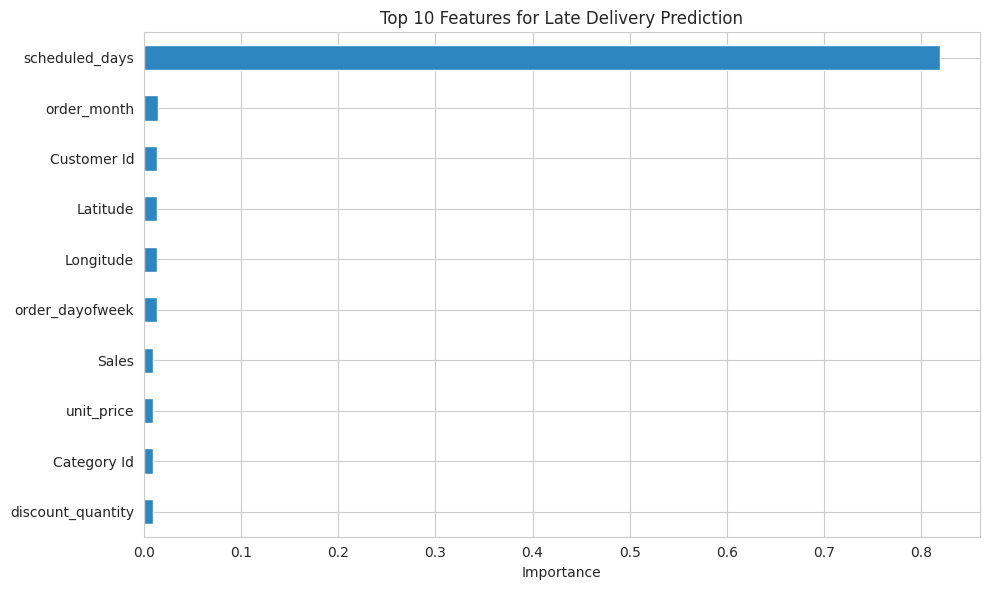

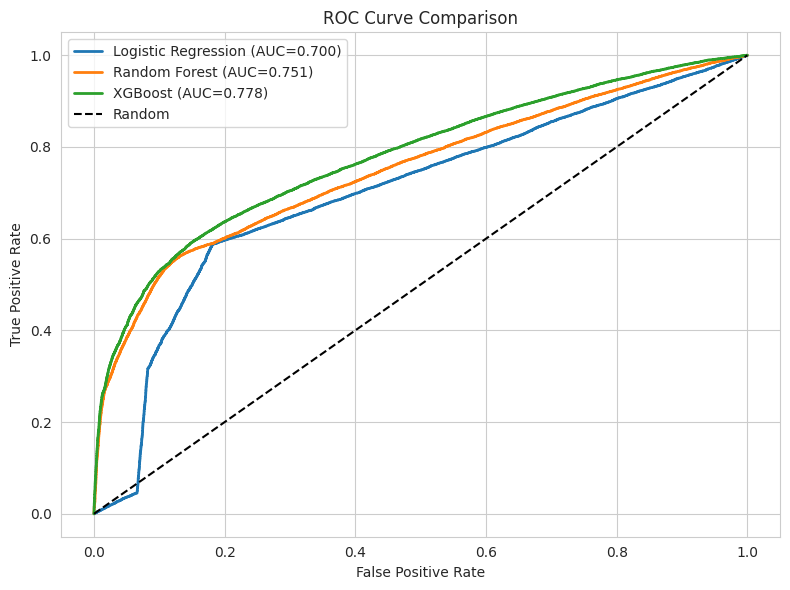

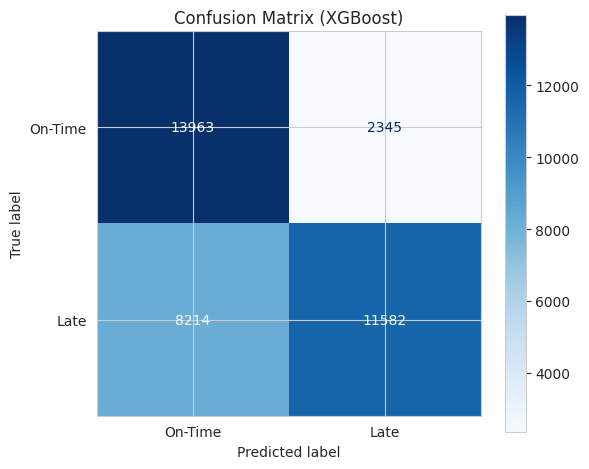

In [ ]:
# 特徵重要性（XGBoost 分類）
importances = pd.Series(xgb.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh', color='#2E86C1')
plt.title('Top 10 Features for Late Delivery Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC 曲線（三模型）
plt.figure(figsize=(8, 6))
for name, (model, X_te) in models.items():
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 混淆矩陣
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['On-Time', 'Late']).plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (XGBoost)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. 門檻調整


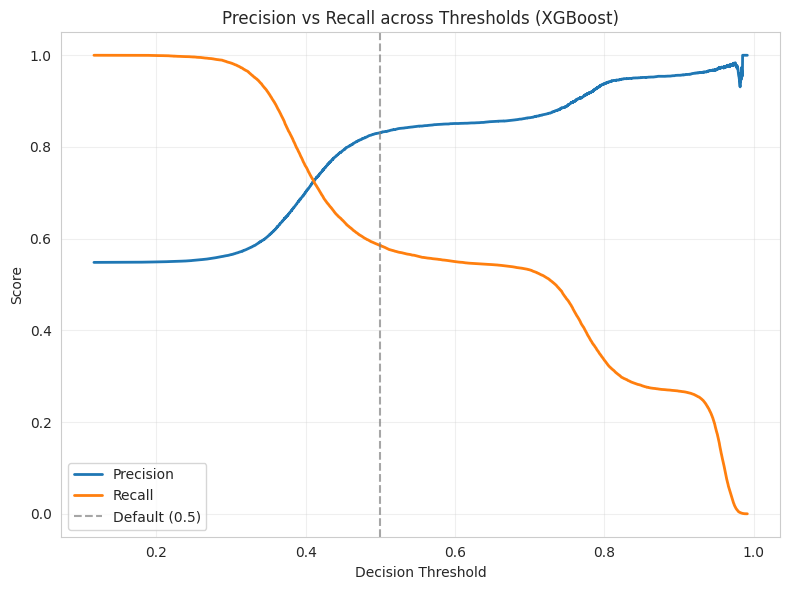

達到 recall≈0.8 需要的門檻約為 0.387

===== 門檻 = 0.500 =====
              precision    recall  f1-score   support

           0      0.630     0.856     0.726     16308
           1      0.832     0.585     0.687     19796

    accuracy                          0.708     36104
   macro avg      0.731     0.721     0.706     36104
weighted avg      0.740     0.708     0.704     36104

===== 門檻 = 0.387 =====
              precision    recall  f1-score   support

           0      0.686     0.531     0.599     16308
           1      0.674     0.800     0.732     19796

    accuracy                          0.679     36104
   macro avg      0.680     0.666     0.665     36104
weighted avg      0.680     0.679     0.672     36104



In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report

# XGBoost 對每筆訂單的「遲到機率」
y_prob = xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# 視覺化
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall across Thresholds (XGBoost)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

# 商業目標至少抓到 80% 的遲到訂單
target_recall = 0.80
idx = np.argmin(np.abs(recalls[:-1] - target_recall))
chosen_threshold = float(thresholds[idx])
print(f"達到 recall≈{target_recall} 需要的門檻約為 {chosen_threshold:.3f}\n")

# 比較預設門檻 vs 調整後門檻
for t in [0.5, chosen_threshold]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"===== 門檻 = {t:.3f} =====")
    print(classification_report(y_test, y_pred_t, digits=3))

# 8. 調整超參數

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),    # 範圍 [0.01, 0.31]
    'subsample': uniform(0.6, 0.4),         # 範圍 [0.6, 1.0]
    'colsample_bytree': uniform(0.6, 0.4),
}

# ---------- 8-1 分類調參 ----------
search_clf = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=SEARCH_N_ITER, scoring='roc_auc', cv=3,
    n_jobs=-1, random_state=42, verbose=1
)
search_clf.fit(X_train, y_train)

xgb_tuned = search_clf.best_estimator_
auc_tuned = roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:, 1])

print("\n【分類調參結果】")
print("最佳參數:", search_clf.best_params_)
print(f"調參前 測試集 ROC-AUC: {xgb_baseline_auc:.3f}")
print(f"調參後 測試集 ROC-AUC: {auc_tuned:.3f}")

# ---------- 8-2 迴歸調參 ----------
search_reg = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=25, scoring='r2', cv=3,
    n_jobs=-1, random_state=42, verbose=1
)
search_reg.fit(Xr_tr, yr_tr)

xgb_reg_tuned = search_reg.best_estimator_
pred_reg_tuned = xgb_reg_tuned.predict(Xr_te)

print("\n【迴歸調參結果】")
print("最佳參數:", search_reg.best_params_)
print(f"調參前 測試集 R²  : {xgb_reg_baseline_r2:.3f}")
print(f"調參後 測試集 R²  : {r2_score(yr_te, pred_reg_tuned):.3f}")
print(f"調參後 測試集 RMSE: {np.sqrt(mean_squared_error(yr_te, pred_reg_tuned)):.3f}")
print(f"調參後 測試集 MAE : {mean_absolute_error(yr_te, pred_reg_tuned):.3f}")
print(f"（對照 Random Forest 迴歸 R² = {r2_score(yr_te, rf_reg.predict(Xr_te)):.3f}）")

Fitting 3 folds for each of 25 candidates, totalling 75 fits

【分類調參結果】
最佳參數: {'colsample_bytree': np.float64(0.9140703845572055), 'learning_rate': np.float64(0.06990213464750791), 'max_depth': 9, 'n_estimators': 343, 'subsample': np.float64(0.836965827544817)}
調參前 測試集 ROC-AUC: 0.778
調參後 測試集 ROC-AUC: 0.814
Fitting 3 folds for each of 25 candidates, totalling 75 fits

【迴歸調參結果】
最佳參數: {'colsample_bytree': np.float64(0.610167650697638), 'learning_rate': np.float64(0.042367428097991336), 'max_depth': 9, 'n_estimators': 330, 'subsample': np.float64(0.7901480892728447)}
調參前 測試集 R²  : 0.405
調參後 測試集 R²  : 0.409
調參後 測試集 RMSE: 1.249
調參後 測試集 MAE : 0.988
（對照 Random Forest 迴歸 R² = 0.445）


# 9. 交叉驗證

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold

# ---------- 9-1 分類 ----------
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_auc = cross_val_score(xgb_tuned, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)

print("\n【分類 5-fold 交叉驗證】")
print(f"ROC-AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"各折: {np.round(cv_auc, 3)}")

# ---------- 9-2 迴歸 ----------
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_r2 = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_reg, y_reg, cv=kf, scoring='r2', n_jobs=-1
)

print("\n【迴歸 5-fold 交叉驗證（Random Forest）】")
print(f"R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"各折: {np.round(cv_r2, 3)}")


【分類 5-fold 交叉驗證】
ROC-AUC: 0.813 ± 0.002
各折: [0.811 0.816 0.811 0.815 0.814]

【迴歸 5-fold 交叉驗證（Random Forest）】
R²: 0.441 ± 0.005
各折: [0.447 0.444 0.435 0.446 0.434]


# 10. SHAP


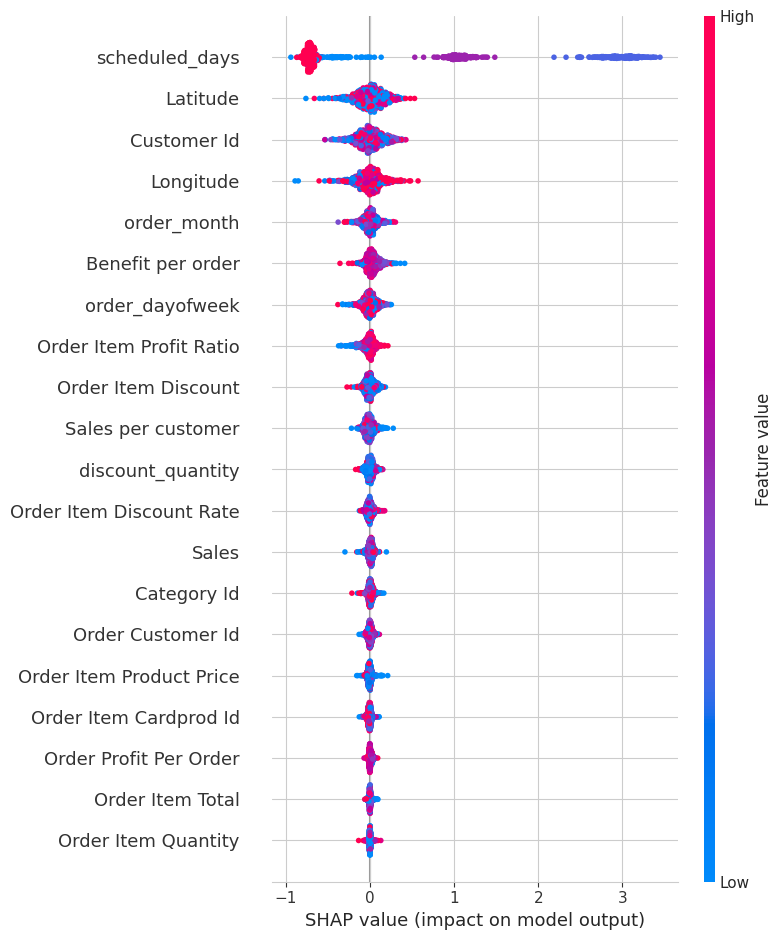

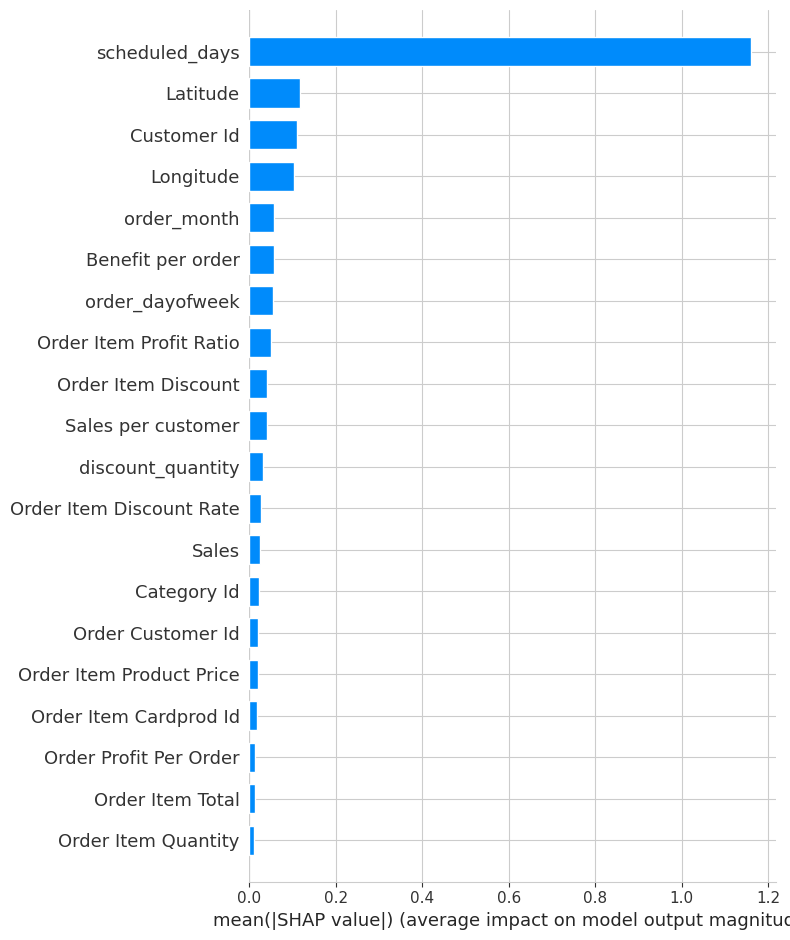

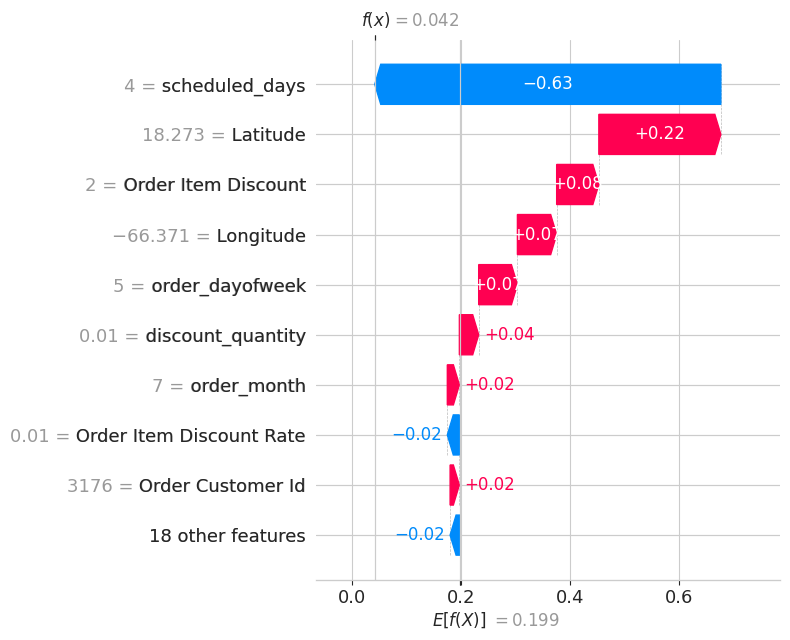

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)

# 取 1000 筆子樣本加速
X_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# 10-1 Beeswarm：每個點是一筆訂單，顏色代表特徵值高低
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 10-2 Bar：平均絕對貢獻（全域重要性）
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 10-3 Waterfall：解釋單一筆訂單的預測
sample_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[sample_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. 模型儲存


In [ ]:
import joblib

joblib.dump(xgb_tuned, 'xgb_late_delivery.pkl')        # 最佳分類模型
joblib.dump(list(X.columns), 'feature_columns.pkl')    # 訓練時的欄位順序（很重要）
joblib.dump(float(chosen_threshold), 'threshold.pkl')  # Section 7 決定的門檻
joblib.dump(xgb_reg_tuned, 'xgb_shipping_days.pkl')    # 最佳迴歸模型（選用）
joblib.dump(list(X_reg.columns), 'reg_columns.pkl')

print("模型pkl檔案已儲存")